# Classification of Facial Attributes on CelebA

This notebook uses a Kaggle dataset of over 200k images of celebrity faces to predict the presence of facial attributes (e.g. bald head, mustache). 

For comparison, a baseline Multi-Layer Perceptron (MLP) and certain variants are created first. Performance, measured by binary accuracy, is further optimised by using an advanced Convolutional Neural Network (CNN).

## Notebook Structure

| Section | Description |
|---------|-------------|
| 0 | Setup & Data|
| 1 | MLP Baseline|
| 2 | MLP Variants |
| 3 | Advanced CNN |
| 4 | Threshold Tuning (exploratory)|

---
## Section 0: Setup & Data

In [1]:
#!pip install "numpy>=1.24,<2" pandas --force-reinstall --no-cache-dir

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns

import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import f1_score, average_precision_score, hamming_loss

import warnings
warnings.filterwarnings('ignore')

2026-03-25 00:39:01.120624: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774399141.322955      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774399141.384624      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774399141.884991      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774399141.885027      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774399141.885030      24 computation_placer.cc:177] computation placer alr

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GPU Check
gpus = tf.config.list_physical_devices('GPU')
print('TensorFlow version:', tf.__version__)
print('GPUs available:', gpus if gpus else 'No GPU - Enable GPU in Kaggle Notebook settings!')
print('GPU model: ', gpus[0].name if gpus else 'No GPU - Enable GPU in Kaggle Notebook settings!')

# Set memory growth to avoid OOM
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Global constants
IMG_SIZE    = 64
BATCH_SIZE  = 128
NUM_CLASSES = 40
AUTOTUNE    = tf.data.AUTOTUNE

# Use Kaggle input directory
BASE_DIR  = '/kaggle/input/datasets/jessicali9530/celeba-dataset'
IMG_DIR   = os.path.join(BASE_DIR, 'img_align_celeba/img_align_celeba')
ATTR_CSV  = os.path.join(BASE_DIR, 'list_attr_celeba.csv')
SPLIT_CSV = os.path.join(BASE_DIR, 'list_eval_partition.csv')

required_paths = [BASE_DIR, IMG_DIR, ATTR_CSV, SPLIT_CSV]
missing_paths = [p for p in required_paths if not os.path.exists(p)]

if missing_paths:
    print('\nWARNING: Missing required data paths:')
    for p in missing_paths:
        print(' -', p)
else:
    print('\nPaths verified. Using Kaggle input folder.')

TensorFlow version: 2.19.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU model:  /physical_device:GPU:0

Paths verified. Using Kaggle input folder.


In [4]:
# Load attribute CSV
attr_df = pd.read_csv(ATTR_CSV)
split_df = pd.read_csv(SPLIT_CSV)

print('Attributes shape:', attr_df.shape)
print('Split CSV shape:', split_df.shape)
print('\nFirst 3 rows of attributes:')
display(attr_df.head(3))
print('\nFirst 3 rows of split file:')
display(split_df.head(3))

# Split dataset according to split_df
split_df.columns = ['image_id', 'partition']
attr_df.rename(columns={'image_id': 'image_id'} if 'image_id' in attr_df.columns else {attr_df.columns[0]: 'image_id'}, inplace=True)

merged_df = pd.merge(split_df, attr_df, on='image_id')
print('Merged shape:', merged_df.shape)

train_df = merged_df[merged_df['partition'] == 0].reset_index(drop=True)
val_df   = merged_df[merged_df['partition'] == 1].reset_index(drop=True)
test_df  = merged_df[merged_df['partition'] == 2].reset_index(drop=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')

# Attribute names
ATTR_NAMES = [c for c in attr_df.columns if c != 'image_id']
print('\n40 Attributes:', ATTR_NAMES)

Attributes shape: (202599, 41)
Split CSV shape: (202599, 2)

First 3 rows of attributes:


,image_id,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
0,000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
1,000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
2,000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1



First 3 rows of split file:


,image_id,partition
0,000001.jpg,0
1,000002.jpg,0
2,000003.jpg,0


Merged shape: (202599, 42)
Train: 162770, Val: 19867, Test: 19962

40 Attributes: ['5_o_Clock_Shadow', 'Arched_Eyebrows', 'Attractive', 'Bags_Under_Eyes', 'Bald', 'Bangs', 'Big_Lips', 'Big_Nose', 'Black_Hair', 'Blond_Hair', 'Blurry', 'Brown_Hair', 'Bushy_Eyebrows', 'Chubby', 'Double_Chin', 'Eyeglasses', 'Goatee', 'Gray_Hair', 'Heavy_Makeup', 'High_Cheekbones', 'Male', 'Mouth_Slightly_Open', 'Mustache', 'Narrow_Eyes', 'No_Beard', 'Oval_Face', 'Pale_Skin', 'Pointy_Nose', 'Receding_Hairline', 'Rosy_Cheeks', 'Sideburns', 'Smiling', 'Straight_Hair', 'Wavy_Hair', 'Wearing_Earrings', 'Wearing_Hat', 'Wearing_Lipstick', 'Wearing_Necklace', 'Wearing_Necktie', 'Young']


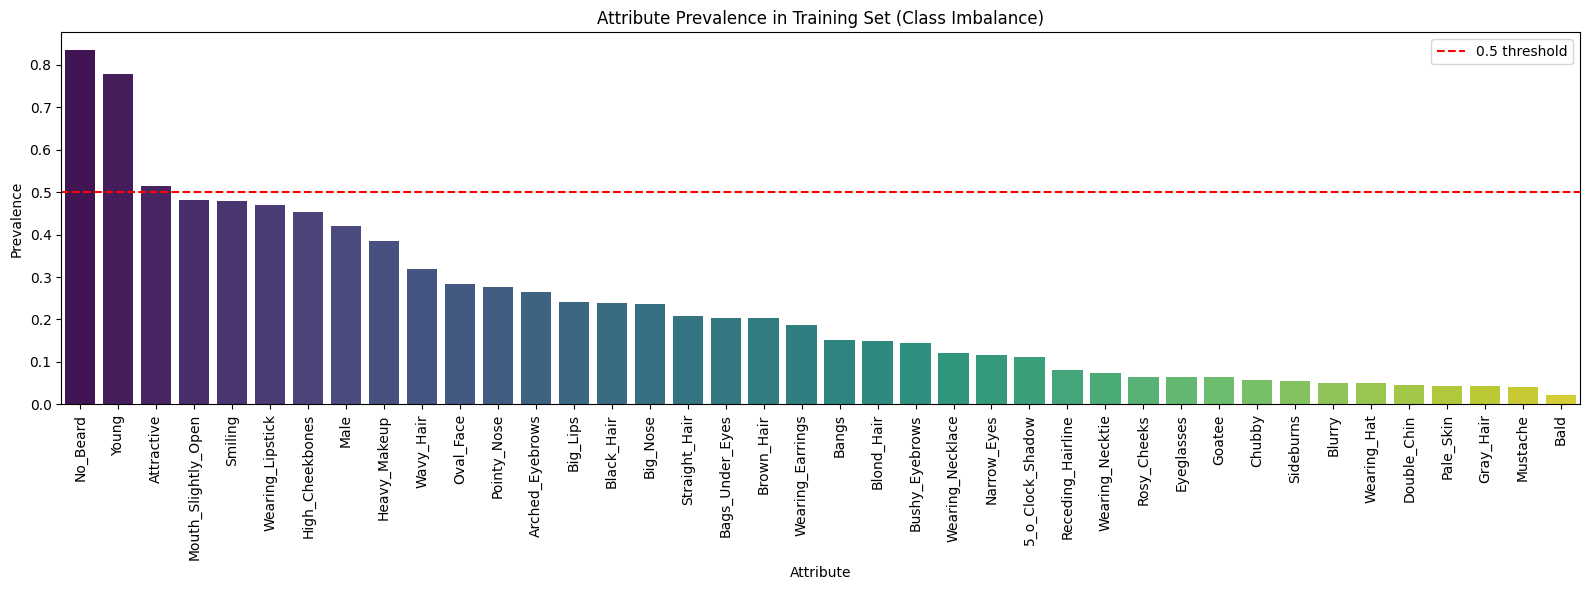

In [5]:
# Preview attributes distribution in training set
label_cols = ATTR_NAMES
# Convert -1 to 0 for analysis
train_labels_np = ((train_df[label_cols].values + 1) // 2).astype(np.float32)
attr_prevalence = train_labels_np.mean(axis=0)

prevalence_df = pd.DataFrame({'Attribute': ATTR_NAMES, 'Prevalence': attr_prevalence})
prevalence_df = prevalence_df.sort_values('Prevalence', ascending=False)

plt.figure(figsize=(16, 6))
sns.barplot(data=prevalence_df, x='Attribute', y='Prevalence', palette='viridis')
plt.xticks(rotation=90)
plt.axhline(0.5, color='red', linestyle='--', label='0.5 threshold')
plt.title('Attribute Prevalence in Training Set (Class Imbalance)')
plt.legend()
plt.tight_layout()
plt.show()

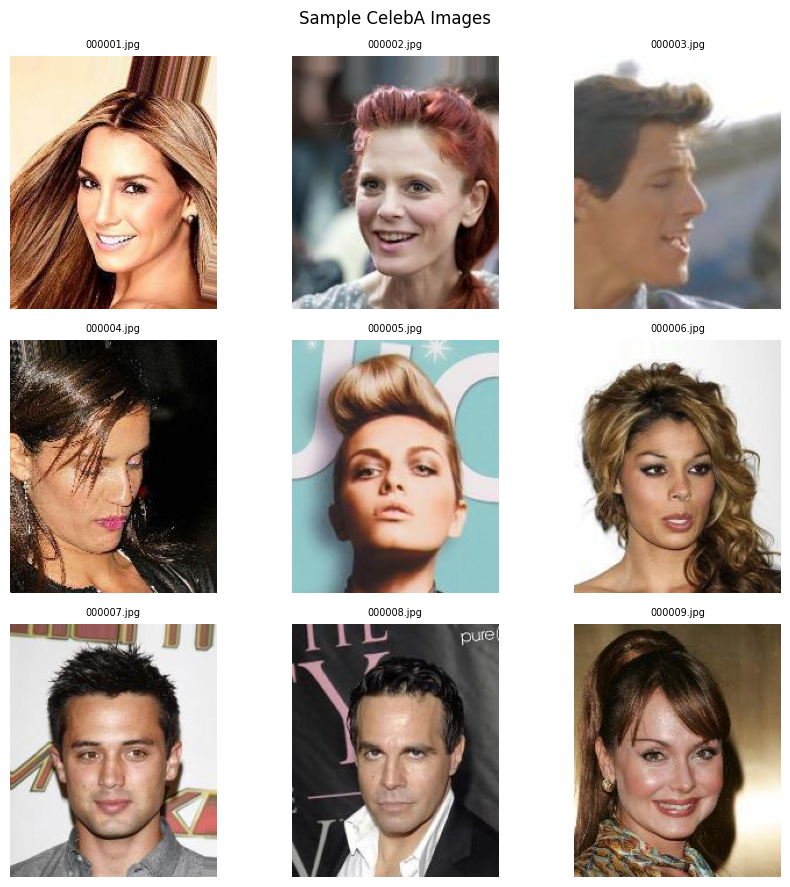

In [6]:
# Visualize sample images
sample_imgs = train_df['image_id'].values[:9]
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for ax, img_name in zip(axes.ravel(), sample_imgs):
    img_path = os.path.join(IMG_DIR, img_name)
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(img_name, fontsize=7)
plt.suptitle('Sample CelebA Images')
plt.tight_layout()
plt.show()

In [7]:
# Efficiently load, resize to 64x64, normalize to [0,1], and cache.
def make_dataset(dataframe, img_dir, attr_names, img_size=64, batch_size=128, shuffle=False, cache=True, augment=False):
    """
    Build a tf.data.Dataset from a DataFrame of image filenames and binary labels.
    - Labels: convert {-1, 1} -> {0, 1}
    - Images: read JPEG, decode, resize, normalize to [0,1]
    - Cache in RAM for speed; shuffle only for training.
    """
    filenames = [os.path.join(img_dir, f) for f in dataframe['image_id'].values]
    labels    = ((dataframe[attr_names].values + 1) // 2).astype(np.float32)

    file_ds  = tf.data.Dataset.from_tensor_slices(filenames)
    label_ds = tf.data.Dataset.from_tensor_slices(labels)
    ds       = tf.data.Dataset.zip((file_ds, label_ds))

    def load_and_preprocess(path, label):
        raw   = tf.io.read_file(path)
        image = tf.image.decode_jpeg(raw, channels=3)
        image = tf.image.resize(image, [img_size, img_size])
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    def augment_fn(image, label):
        image = tf.image.random_flip_left_right(image)
        image = tf.image.random_brightness(image, 0.15)
        image = tf.image.random_contrast(image, 0.85, 1.15)
        image = tf.clip_by_value(image, 0.0, 1.0)
        return image, label

    ds = ds.map(load_and_preprocess, num_parallel_calls=AUTOTUNE)
    if cache:
        ds = ds.cache()
    if shuffle:
        ds = ds.shuffle(buffer_size=8000, seed=SEED)
    if augment:
        ds = ds.map(augment_fn, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

print('Building datasets...')
train_ds      = make_dataset(train_df, IMG_DIR, ATTR_NAMES, shuffle=True, augment=True)   # for CNNs
train_ds_noaug = make_dataset(train_df, IMG_DIR, ATTR_NAMES, shuffle=True, augment=False)  # for MLPs
val_ds        = make_dataset(val_df,   IMG_DIR, ATTR_NAMES)
test_ds       = make_dataset(test_df,  IMG_DIR, ATTR_NAMES)
print('Datasets ready.')

Building datasets...


I0000 00:00:1774399169.427504      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Datasets ready.


---
## Section 1: MLP Baseline

In [8]:
class MacroF1Score(tf.keras.metrics.Metric):
    def __init__(self, num_classes=40, threshold=0.5, name='macro_f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.threshold = threshold
        self.tp = self.add_weight(shape=(num_classes,), initializer='zeros', name='tp')
        self.fp = self.add_weight(shape=(num_classes,), initializer='zeros', name='fp')
        self.fn = self.add_weight(shape=(num_classes,), initializer='zeros', name='fn')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred >= self.threshold, tf.float32)
        y_true = tf.cast(y_true, tf.float32)
        self.tp.assign_add(tf.reduce_sum(y_true * y_pred, axis=0))
        self.fp.assign_add(tf.reduce_sum((1 - y_true) * y_pred, axis=0))
        self.fn.assign_add(tf.reduce_sum(y_true * (1 - y_pred), axis=0))

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall    = self.tp / (self.tp + self.fn + 1e-7)
        f1_per_class = 2 * precision * recall / (precision + recall + 1e-7)
        return tf.reduce_mean(f1_per_class)

    def reset_state(self):
        self.tp.assign(tf.zeros(self.num_classes))
        self.fp.assign(tf.zeros(self.num_classes))
        self.fn.assign(tf.zeros(self.num_classes))

In [9]:
class FullMetricsCallback(tf.keras.callbacks.Callback):
    """
    Computes Hamming loss, micro/macro-F1, and micro/macro-mAP on the
    validation set at the end of each epoch and stores them in history.
    Runs evaluate_model() so results are consistent with final reporting.
    """
    def __init__(self, val_dataset):
        super().__init__()
        self.val_dataset = val_dataset
        self.metric_keys = ['hamming_loss', 'micro_f1', 'macro_f1_full',
                            'micro_map', 'macro_map']

    def on_epoch_end(self, epoch, logs=None):
        results, _, _ = evaluate_model(self.model, self.val_dataset,
                                       label=f'Epoch {epoch+1}')
        logs['val_hamming_loss'] = results['Hamming Loss']
        logs['val_micro_f1']     = results['Micro-F1']
        logs['val_macro_f1_full']= results['Macro-F1']
        logs['val_micro_map']    = results['Micro-mAP']
        logs['val_macro_map']    = results['Macro-mAP']

full_metrics_cb = FullMetricsCallback(val_ds)
print('FullMetricsCallback defined.')

FullMetricsCallback defined.


In [10]:
def get_predictions(model, dataset):
    """Run inference on a tf.data.Dataset and return (y_true, y_prob)."""
    y_true_list, y_prob_list = [], []
    for images, labels in dataset:
        probs = model.predict(images, verbose=0)
        y_true_list.append(labels.numpy())
        y_prob_list.append(probs)
    y_true = np.vstack(y_true_list)  # (N, 40)
    y_prob = np.vstack(y_prob_list)  # (N, 40) sigmoid probabilities
    return y_true, y_prob

print('Helper for getting predictions defined.')

Helper for getting predictions defined.


In [11]:
def evaluate_model(model, dataset, threshold=0.5, label='Test'):
    """
    Compute and print all required metrics:
      - Binary Accuracy (per-label avg, threshold=0.5)
      - Hamming Loss
      - Micro-F1 and Macro-F1
      - Micro-mAP and Macro-mAP
    """
    y_true, y_prob = get_predictions(model, dataset)

    if np.ndim(threshold) == 0:
        # scalar threshold
        y_pred = (y_prob >= threshold).astype(int)
    else:
        # per-attribute thresholds vector of shape (40,)
        y_pred = (y_prob >= threshold[np.newaxis, :]).astype(int)

    bin_acc    = np.mean(y_pred == y_true)
    h_loss     = hamming_loss(y_true, y_pred)
    micro_f1   = f1_score(y_true, y_pred, average='micro', zero_division=0)
    macro_f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    micro_map  = average_precision_score(y_true, y_prob, average='micro')
    macro_map  = average_precision_score(y_true, y_prob, average='macro')

    results = {
        'Binary Accuracy': bin_acc,
        'Hamming Loss':    h_loss,
        'Micro-F1':        micro_f1,
        'Macro-F1':        macro_f1,
        'Micro-mAP':       micro_map,
        'Macro-mAP':       macro_map
    }

    print(f'\n--- {label} Metrics (threshold={np.round(threshold, 3) if np.ndim(threshold)==0 else "per-attr"}) ---')
    for k, v in results.items():
        print(f'  {k:20s}: {v:.4f}')

    return results, y_true, y_prob

print('Helper for evaluating model defined.')

Helper for evaluating model defined.


In [12]:
def plot_training_history(history, title='Training History'):
    h = history.history
    has_f1  = 'macro_f1' in h           # live MacroF1Score metric
    has_full = 'val_macro_f1_full' in h  # from FullMetricsCallback

    panels = [('Loss', 'loss', 'val_loss')]
    panels.append(('Binary Accuracy', 'binary_accuracy', 'val_binary_accuracy'))
    if has_f1:
        panels.append(('Macro-F1 (train metric)', 'macro_f1', 'val_macro_f1'))
    if has_full:
        panels.append(('Hamming Loss (val)', None, 'val_hamming_loss'))
        panels.append(('Micro-F1 (val)',     None, 'val_micro_f1'))
        panels.append(('Macro-F1 (val)',     None, 'val_macro_f1_full'))
        panels.append(('Micro-mAP (val)',    None, 'val_micro_map'))
        panels.append(('Macro-mAP (val)',    None, 'val_macro_map'))

    ncols = min(len(panels), 4)
    nrows = (len(panels) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
    axes = np.array(axes).flatten()

    for ax, (title_p, train_key, val_key) in zip(axes, panels):
        if train_key and train_key in h:
            ax.plot(h[train_key], label='Train')
        if val_key and val_key in h:
            ax.plot(h[val_key],   label='Val')
        ax.set_title(title_p)
        ax.set_xlabel('Epoch')
        ax.legend()

    for ax in axes[len(panels):]:
        ax.set_visible(False)

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [13]:
def build_mlp_q1(input_shape=(64, 64, 3), num_classes=40):
    """
    MLP Baseline:
      Flatten -> Dense(512, relu) 
             -> Dense(256, relu) 
             -> Dense(40, sigmoid)
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='sigmoid')   # sigmoid per attribute
    ], name='MLP_Baseline')
    return model
    
mlp_model = build_mlp_q1()
mlp_model.summary()
mlp_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['binary_accuracy', MacroF1Score(num_classes=NUM_CLASSES)]
)


Model: "MLP_Baseline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 12288)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     6,291,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,433,576 (24.54 MB)

 Trainable params: 6,433,576 (24.54 MB)

 Non-trainable params: 0 (0.00 B)

Training MLP...
Epoch 1/50


I0000 00:00:1774399186.218540      69 service.cc:152] XLA service 0x781d0000aeb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774399186.218583      69 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774399186.590224      69 cuda_dnn.cc:529] Loaded cuDNN version 91002


   1/1272 ━━━━━━━━━━━━━━━━━━━━ 5:04:08 14s/step - binary_accuracy: 0.4633 - loss: 0.7517 - macro_f1: 0.2359

I0000 00:00:1774399187.459087      69 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 215ms/step - binary_accuracy: 0.8406 - loss: 0.3817 - macro_f1: 0.2860
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8673
  Hamming Loss        : 0.1327
  Micro-F1            : 0.6707
  Macro-F1            : 0.3993
  Micro-mAP           : 0.7793
  Macro-mAP           : 0.5676
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 338s 254ms/step - binary_accuracy: 0.8406 - loss: 0.3817 - macro_f1: 0.2861 - val_binary_accuracy: 0.8673 - val_loss: 0.3041 - val_macro_f1: 0.3993 - val_hamming_loss: 0.1327 - val_micro_f1: 0.6707 - val_macro_f1_full: 0.3993 - val_micro_map: 0.7793 - val_macro_map: 0.5676
Epoch 2/50
1265/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.8714 - loss: 0.2964 - macro_f1: 0.4344
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8785
  Hamming Loss        : 0.1215
  Micro-F1            : 0.6859
  Macro-F1            : 0.4563
  Micro-mAP           : 0.8073
  Macro-mAP           : 0.5975
1272/1272 ━━━━━━━━━━━━━━

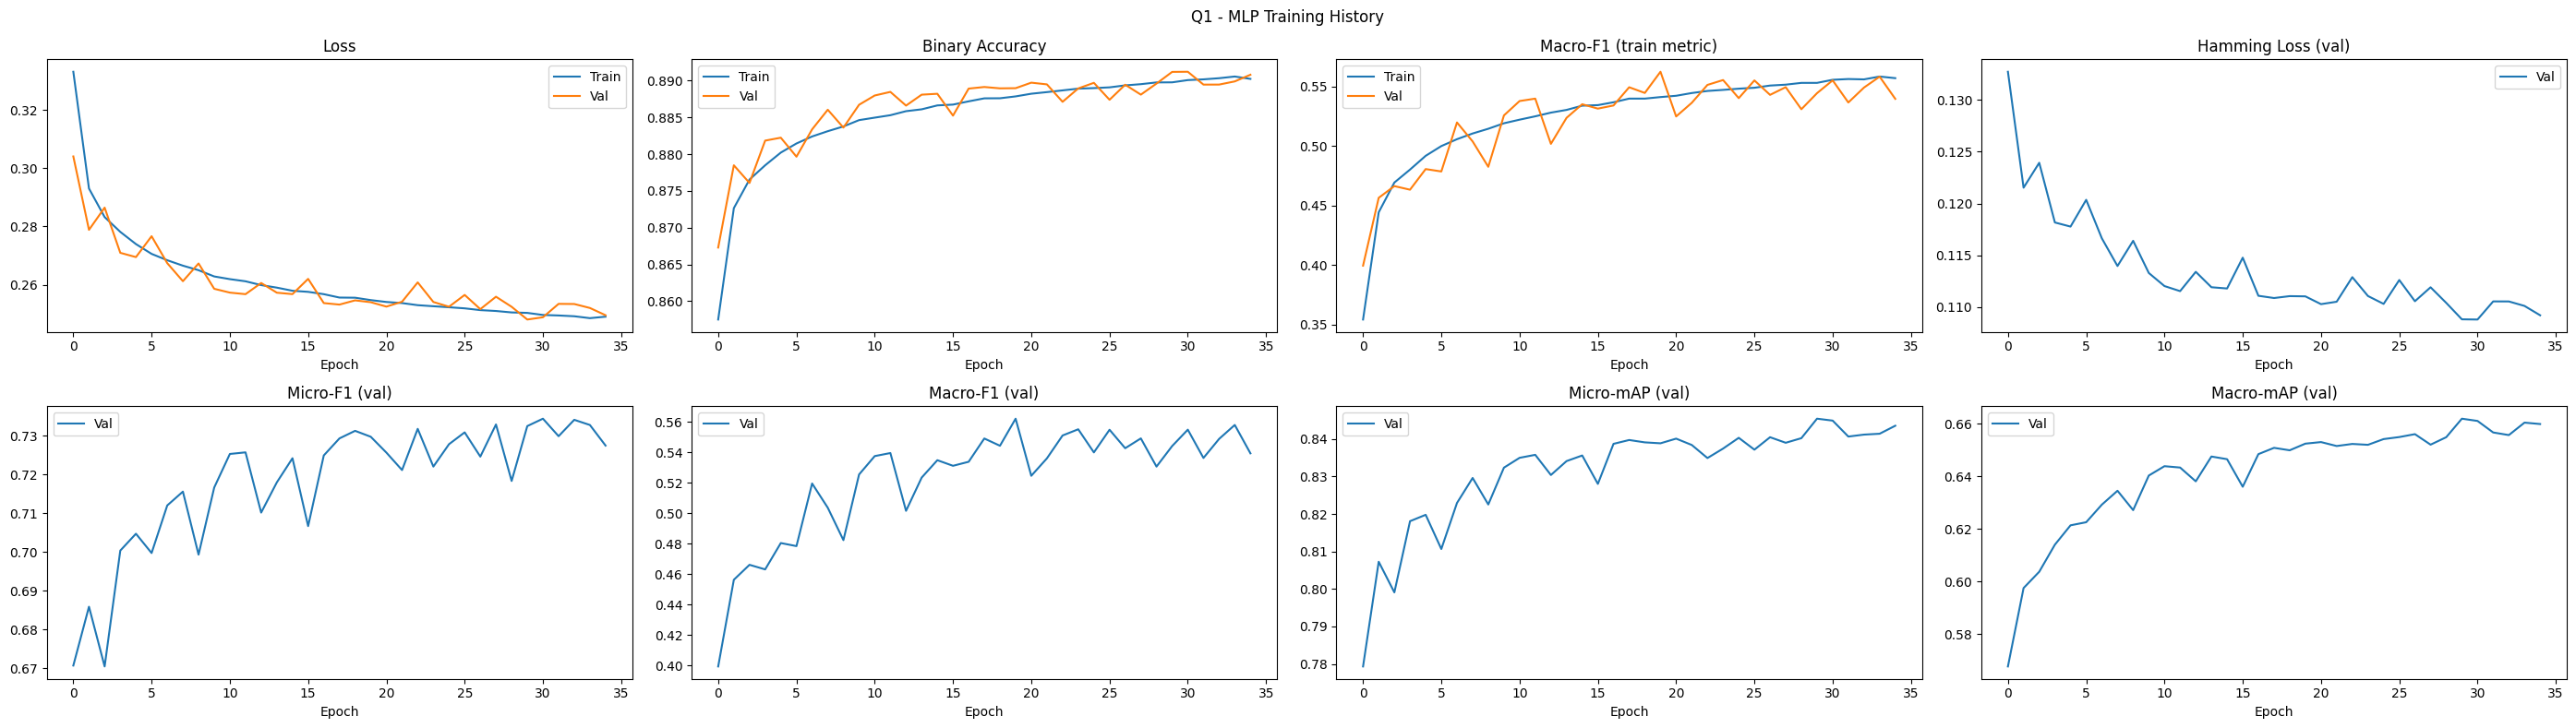

In [14]:
Q1_WEIGHTS = 'q1_mlp.weights.h5'

callbacks_q1 = [
    full_metrics_cb,
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', verbose=1),
    ModelCheckpoint(Q1_WEIGHTS, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=0)
]

print('Training MLP...')
history_q1 = mlp_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_q1,
    verbose=1
)

plot_training_history(history_q1, title='Q1 - MLP Training History')

In [15]:
print('Loading best Q1 weights...')
mlp_model.load_weights(Q1_WEIGHTS)

q1_val_results,  _, _ = evaluate_model(mlp_model, val_ds,  label='Q1 Val')
q1_test_results, _, _ = evaluate_model(mlp_model, test_ds, label='Q1 Test')

Loading best Q1 weights...

--- Q1 Val Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8912
  Hamming Loss        : 0.1088
  Micro-F1            : 0.7325
  Macro-F1            : 0.5442
  Micro-mAP           : 0.8454
  Macro-mAP           : 0.6619

--- Q1 Test Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8865
  Hamming Loss        : 0.1135
  Micro-F1            : 0.7291
  Macro-F1            : 0.5449
  Micro-mAP           : 0.8477
  Macro-mAP           : 0.6616


### Section 1 Analysis

* **Training vs validation**: Training Loss shows a smooth, consistent decline from approximately 0.33 to 0.25. Meanwhile, the Validatoin curve follows a similar path from 0.25 but with lesser stability, characterized by a more jagged line.

* **Final test performance**: The MLP baseline achieves 88.7% binary accuracy and 54.5% Macro-F1 on the test set, which was achieved on epoch 30 out of a total of 35 epochs run.

* **Overfitting**: The "jagged" nature of the validation curves (especially in F1 and mAP) indicates that the model is becoming overly sensitive to specific patterns or noise in the training data that do not exist in the validation set.

---
## Section 2: Improved MLP Variants

In [16]:
# Retry with different MLP architecture (all variants include BatchNorm + Dropout)

def build_mlp_q2_1(input_shape=(64, 64, 3), num_classes=40):
    """
    MLP with one hidden layer: Using Pre-Activation Batch Normalization
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        layers.Dense(512, use_bias=False), # BN handles bias
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        layers.Dense(num_classes, activation='sigmoid')
    ], name='MLP_OneHiddenLayer_Optimized')
    return model

def build_mlp_q2_2(input_shape=(64, 64, 3), num_classes=40):
    """
    Deeper MLP: Gradual bottleneck with Dropout scaling
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        
        layers.Dense(1024, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(512, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(256, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),
        
        layers.Dense(128, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.1),
        
        layers.Dense(num_classes, activation='sigmoid')
    ], name='MLP_Deeper_Optimized')
    return model

def build_mlp_q2_3(input_shape=(64, 64, 3), num_classes=40):
    """
    Wider MLP: Stronger initial capacity
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Flatten(),
        
        layers.Dense(1024, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.3),
        
        layers.Dense(512, use_bias=False),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        
        layers.Dense(num_classes, activation='sigmoid')
    ], name='MLP_Wider_Optimized')
    return model

In [17]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5, 
    patience=3, 
    min_lr=1e-6, 
    verbose=1
)

In [18]:
def train_mlp_variant(model, weight_path, title):
    # Implementing Weight Decay directly in the Adam optimizer (AdamW pattern)
    # A value of 1e-4 or 1e-5 is usually the "sweet spot"
    opt = keras.optimizers.Adam(learning_rate=1e-3, weight_decay=1e-5)
    
    model.compile(
        optimizer=opt,
        loss='binary_crossentropy',
        metrics=['binary_accuracy', MacroF1Score(num_classes=NUM_CLASSES)]
    )
    
    callbacks = [
        full_metrics_cb,
        reduce_lr,
        EarlyStopping(patience=10, restore_best_weights=True, monitor='val_loss', verbose=1),
        ModelCheckpoint(weight_path, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=0)
    ]
    
    print(f'\nTraining {title} (with Weight Decay)...')
    history = model.fit(
        train_ds_noaug, 
        validation_data=val_ds, 
        epochs=50, 
        callbacks=callbacks, 
        verbose=1
    )
    
    plot_training_history(history, title=title)
    return history


Training Q2.1 - One Hidden Layer (with Weight Decay)...
Epoch 1/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - binary_accuracy: 0.8528 - loss: 0.3415 - macro_f1: 0.3814
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8764
  Hamming Loss        : 0.1236
  Micro-F1            : 0.6814
  Macro-F1            : 0.3941
  Micro-mAP           : 0.7952
  Macro-mAP           : 0.5856
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 102s 75ms/step - binary_accuracy: 0.8529 - loss: 0.3415 - macro_f1: 0.3815 - val_binary_accuracy: 0.8764 - val_loss: 0.2976 - val_macro_f1: 0.3941 - val_hamming_loss: 0.1236 - val_micro_f1: 0.6814 - val_macro_f1_full: 0.3941 - val_micro_map: 0.7952 - val_macro_map: 0.5856 - learning_rate: 0.0010
Epoch 2/50
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - binary_accuracy: 0.8799 - loss: 0.2766 - macro_f1: 0.4933
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8784
  Hamming Loss        : 0.1216
  Micro-F1            : 0.6707
  Macro-F1            : 0.3

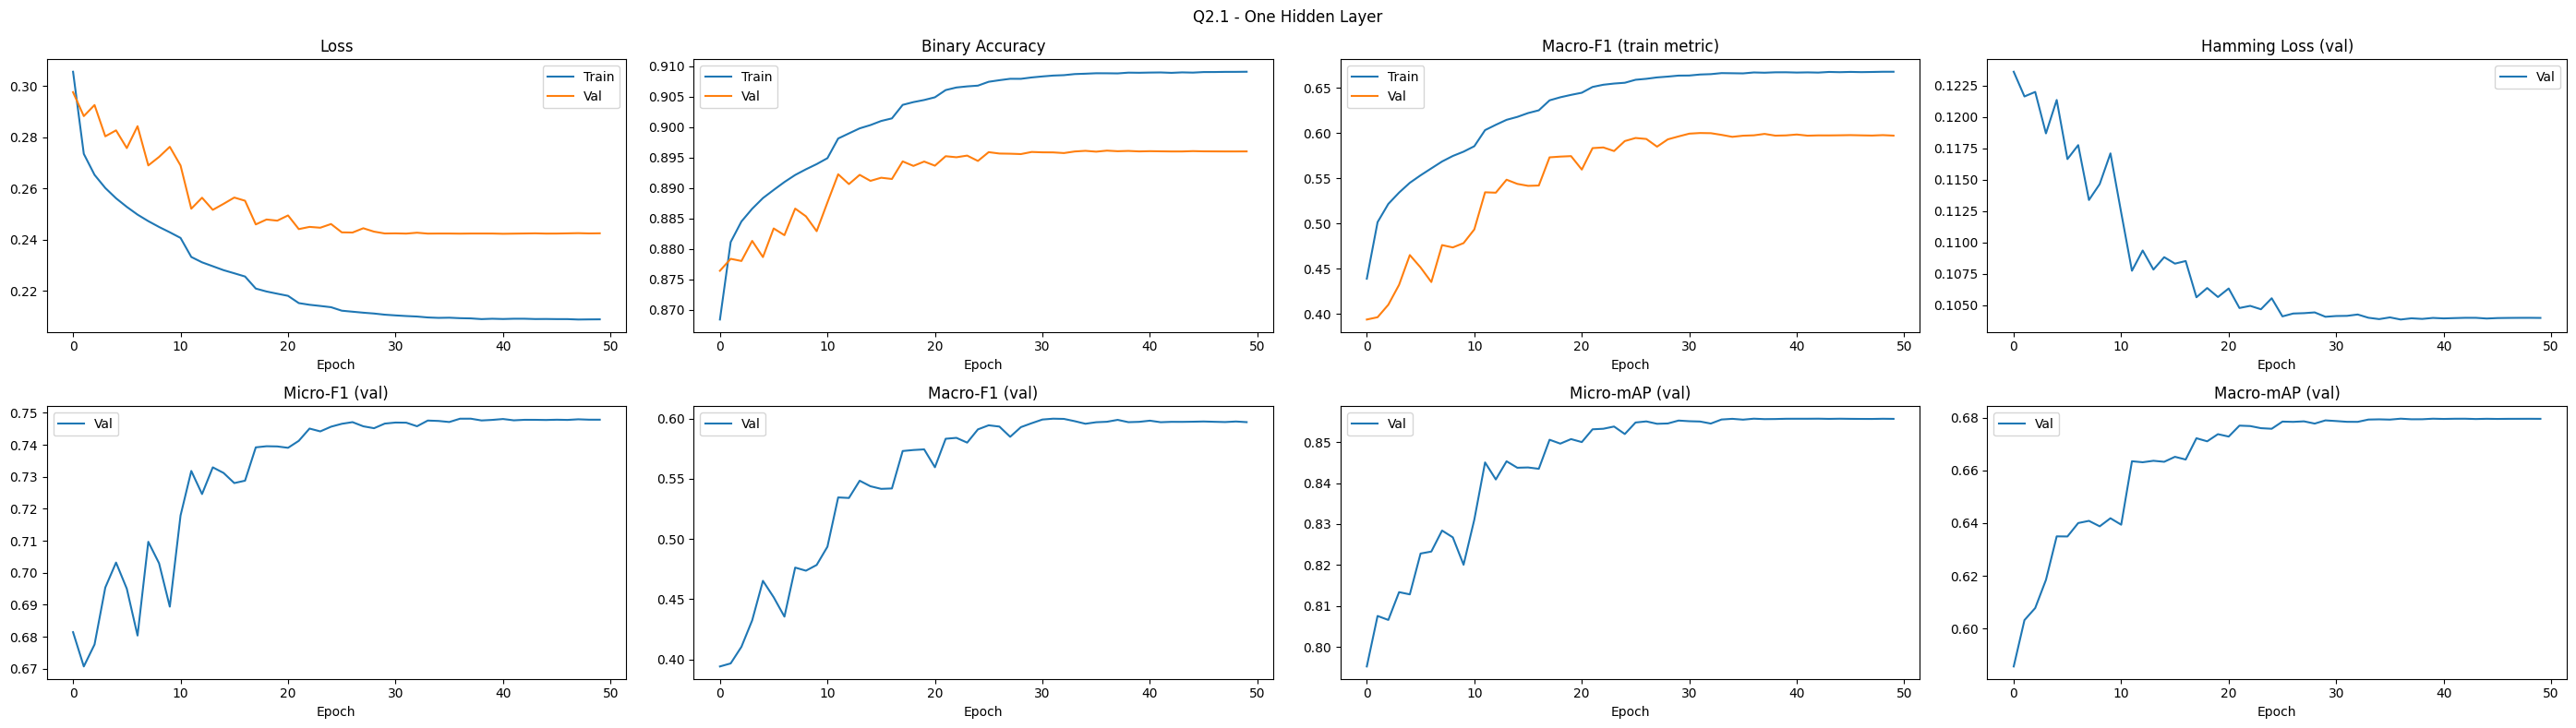

In [19]:
mlp_q2_1 = build_mlp_q2_1()
history_q2_1 = train_mlp_variant(mlp_q2_1, 'q2_mlp_1.weights.h5', 'Q2.1 - One Hidden Layer')


Training Q2.2 - Deeper MLP (with Weight Decay)...
Epoch 1/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - binary_accuracy: 0.8306 - loss: 0.3732 - macro_f1: 0.3159
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8671
  Hamming Loss        : 0.1329
  Micro-F1            : 0.6405
  Macro-F1            : 0.3824
  Micro-mAP           : 0.7722
  Macro-mAP           : 0.5712
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - binary_accuracy: 0.8307 - loss: 0.3731 - macro_f1: 0.3159 - val_binary_accuracy: 0.8671 - val_loss: 0.3060 - val_macro_f1: 0.3824 - val_hamming_loss: 0.1329 - val_micro_f1: 0.6405 - val_macro_f1_full: 0.3824 - val_micro_map: 0.7722 - val_macro_map: 0.5712 - learning_rate: 0.0010
Epoch 2/50
1266/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.8755 - loss: 0.2852 - macro_f1: 0.4500
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8738
  Hamming Loss        : 0.1262
  Micro-F1            : 0.6719
  Macro-F1            : 0.4289
  M

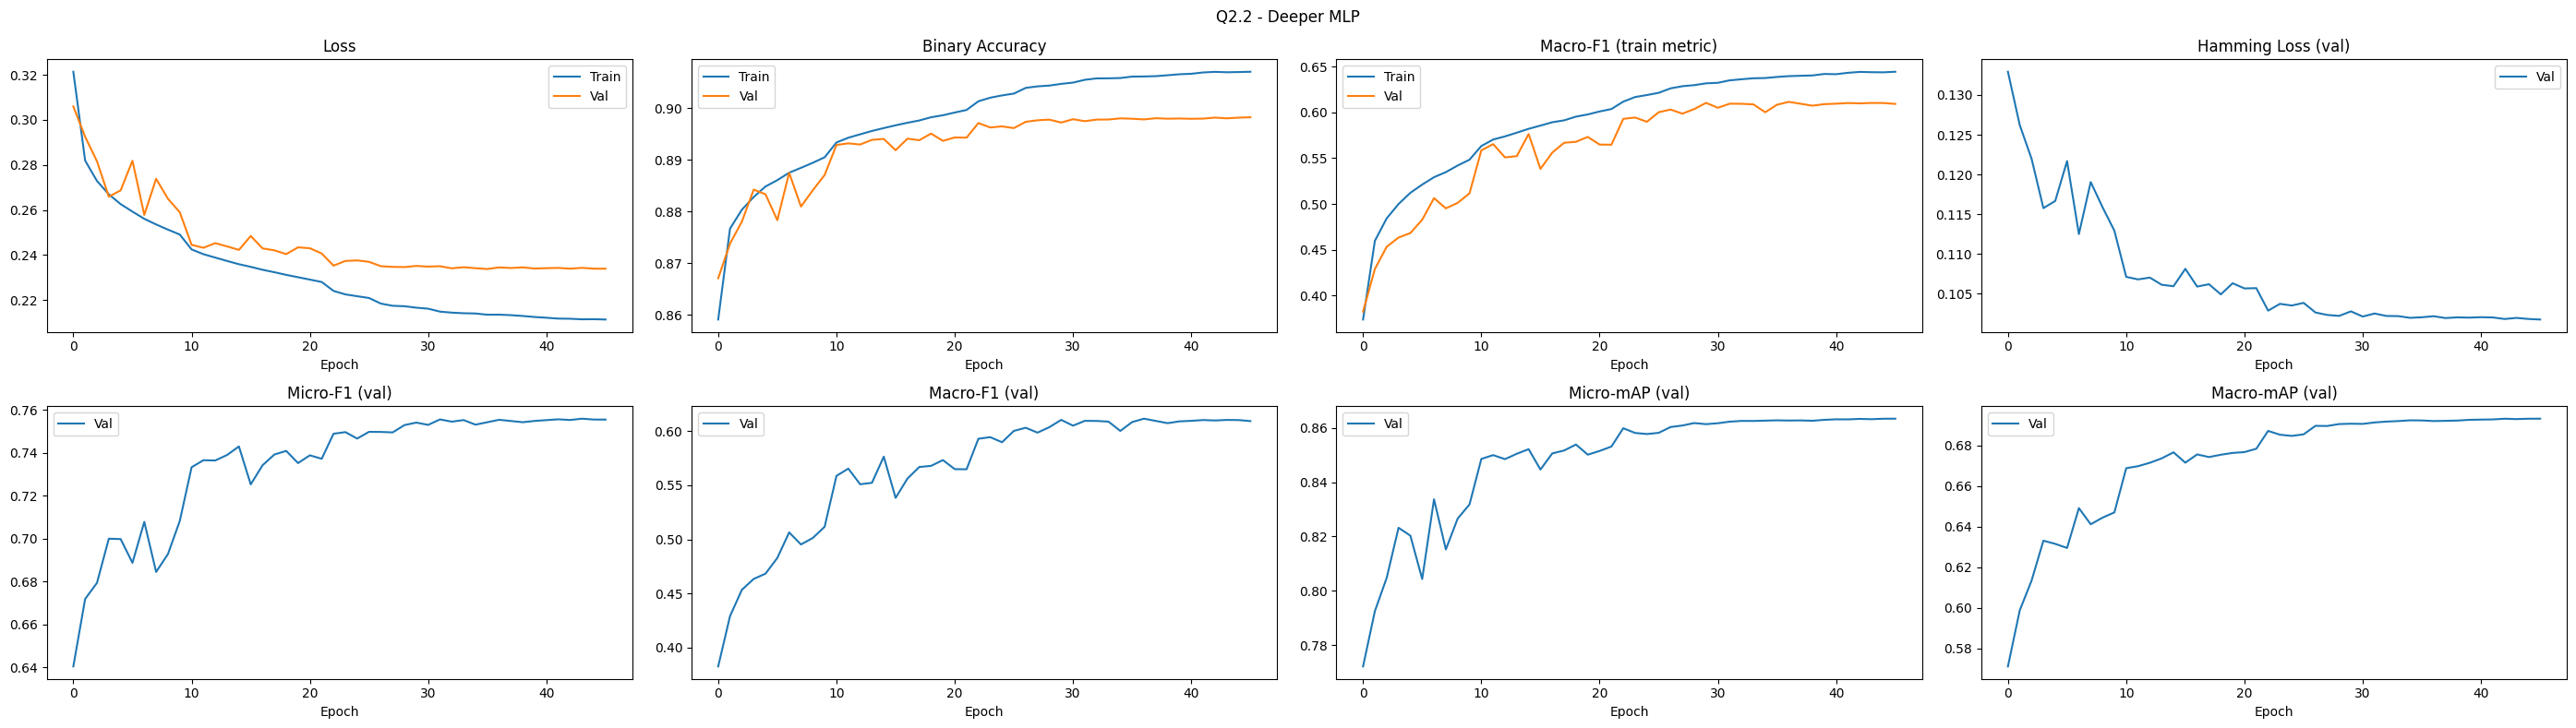

In [20]:
mlp_q2_2 = build_mlp_q2_2()
history_q2_2 = train_mlp_variant(mlp_q2_2, 'q2_mlp_2.weights.h5', 'Q2.2 - Deeper MLP')


Training Q2.3 - Wider MLP (with Weight Decay)...
Epoch 1/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - binary_accuracy: 0.8515 - loss: 0.3385 - macro_f1: 0.3690
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8740
  Hamming Loss        : 0.1260
  Micro-F1            : 0.6913
  Macro-F1            : 0.4727
  Micro-mAP           : 0.7958
  Macro-mAP           : 0.5882
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - binary_accuracy: 0.8515 - loss: 0.3385 - macro_f1: 0.3691 - val_binary_accuracy: 0.8740 - val_loss: 0.2982 - val_macro_f1: 0.4727 - val_hamming_loss: 0.1260 - val_micro_f1: 0.6913 - val_macro_f1_full: 0.4727 - val_micro_map: 0.7958 - val_macro_map: 0.5882 - learning_rate: 0.0010
Epoch 2/50
1269/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - binary_accuracy: 0.8792 - loss: 0.2762 - macro_f1: 0.4841
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8742
  Hamming Loss        : 0.1258
  Micro-F1            : 0.6660
  Macro-F1            : 0.4616
  Mic

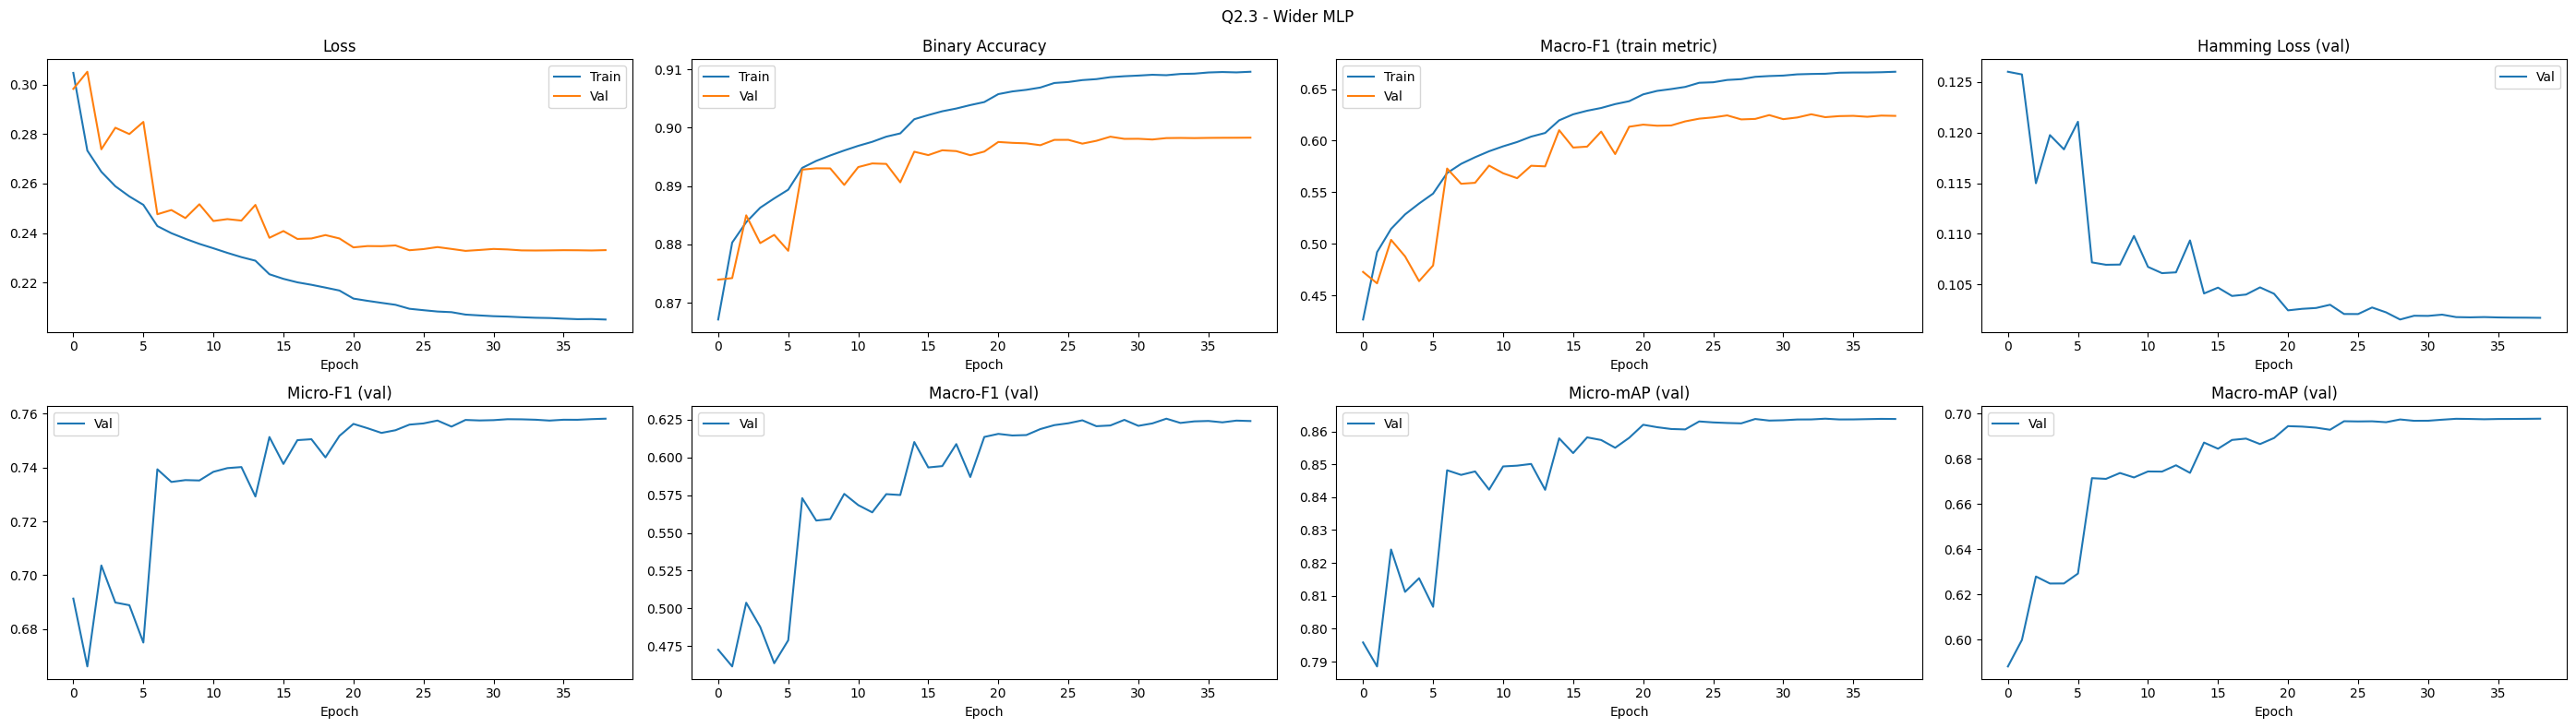

In [21]:
mlp_q2_3 = build_mlp_q2_3()
history_q2_3 = train_mlp_variant(mlp_q2_3, 'q2_mlp_3.weights.h5', 'Q2.3 - Wider MLP')

In [22]:
# Define weight paths if not already defined globally
Q2_1_WEIGHTS = 'q2_mlp_1.weights.h5'
Q2_2_WEIGHTS = 'q2_mlp_2.weights.h5'
Q2_3_WEIGHTS = 'q2_mlp_3.weights.h5'

print('Loading best weights for Q2 MLP variants...')
# Load the weights restored by the ModelCheckpoint callback
mlp_q2_1.load_weights(Q2_1_WEIGHTS)
mlp_q2_2.load_weights(Q2_2_WEIGHTS)
mlp_q2_3.load_weights(Q2_3_WEIGHTS)

# Evaluate each variant
q2_1_val_results, _, _ = evaluate_model(mlp_q2_1, val_ds, label='Q2.1 Val (One Hidden Layer)')
q2_1_test_results, _, _ = evaluate_model(mlp_q2_1, test_ds, label='Q2.1 Test (One Hidden Layer)')

q2_2_val_results, _, _ = evaluate_model(mlp_q2_2, val_ds, label='Q2.2 Val (Deeper)')
q2_2_test_results, _, _ = evaluate_model(mlp_q2_2, test_ds, label='Q2.2 Test (Deeper)')

q2_3_val_results, _, _ = evaluate_model(mlp_q2_3, val_ds, label='Q2.3 Val (Wider)')
q2_3_test_results, _, _ = evaluate_model(mlp_q2_3, test_ds, label='Q2.3 Test (Wider)')

# Compile summary table
val_summary_q2 = pd.DataFrame([
    {'Model': 'Q2.1 One Hidden Layer', **q2_1_val_results},
    {'Model': 'Q2.2 Deeper',            **q2_2_val_results},
    {'Model': 'Q2.3 Wider',             **q2_3_val_results},
]).set_index('Model').round(4)

print('\nValidation summary (Q2 variants):')
display(val_summary_q2)

# Select best model by validation Macro-F1
best_model_name = val_summary_q2['Macro-F1'].idxmax()
q2_model_map = {
    'Q2.1 One Hidden Layer': mlp_q2_1,
    'Q2.2 Deeper': mlp_q2_2,
    'Q2.3 Wider': mlp_q2_3,
}
q2_best_model = q2_model_map[best_model_name]

print(f"\nSelected q2_best_model: {best_model_name}")
print(f"Best validation Macro-F1: {val_summary_q2.loc[best_model_name, 'Macro-F1']:.4f}")

Loading best weights for Q2 MLP variants...

--- Q2.1 Val (One Hidden Layer) Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8961
  Hamming Loss        : 0.1039
  Micro-F1            : 0.7480
  Macro-F1            : 0.5984
  Micro-mAP           : 0.8557
  Macro-mAP           : 0.6795

--- Q2.1 Test (One Hidden Layer) Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8913
  Hamming Loss        : 0.1087
  Micro-F1            : 0.7433
  Macro-F1            : 0.5919
  Micro-mAP           : 0.8581
  Macro-mAP           : 0.6813

--- Q2.2 Val (Deeper) Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8980
  Hamming Loss        : 0.1020
  Micro-F1            : 0.7543
  Macro-F1            : 0.6085
  Micro-mAP           : 0.8627
  Macro-mAP           : 0.6924

--- Q2.2 Test (Deeper) Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8929
  Hamming Loss        : 0.1071
  Micro-F1            : 0.7490
  Macro-F1            : 0.6023
  Micro-mAP           : 0.8638
  Macro-mAP      

,Binary Accuracy,Hamming Loss,Micro-F1,Macro-F1,Micro-mAP,Macro-mAP
Model,,,,,,
Q2.1 One Hidden Layer,0.8961,0.1039,0.7480,0.5984,0.8557,0.6795
Q2.2 Deeper,0.8980,0.1020,0.7543,0.6085,0.8627,0.6924
Q2.3 Wider,0.8985,0.1015,0.7577,0.6211,0.8638,0.6973



Selected q2_best_model: Q2.3 Wider
Best validation Macro-F1: 0.6211


## Section 2 Analysis:

* **Improvements in validatoin performance**: Higher macro-F1 (0.6211) compared to the baseline model (0.5442). Higher binary accuracy (0.8985) compared to baseline model (0.8912).

* **Improvements in test performance**: Higher macro-F1 (0.6143) compared to the baseline model (0.5449). Higher binary accuracy (0.8933) compared to baseline model (0.8865).

* **Improvements in training stability**: Training is more stable with lesser volatility in the Macro F1 curves. Validation loss moves steadily towards the global minimum.

* **Impact of network depth and width**: Increasing the width to 1024 neurons allowed the model to better capture the complexities of the flattened input. Since the wide model achieved the best results, this suggests that for this specific dataset, "breadth" was more critical than "depth" to avoid the diminishing returns often associated with narrow, deep architectures in MLP settings.

* **Impact of learning rate scheduling**: By "stepping down" the learning rate when progress plateaued, the model was able to settle into a better local optimum, pushing the Macro-F1 past the 0.60 threshold—a level the baseline was unable to reach.

* **Impact of regularisation techniques**:The combination of scaled Dropout (0.1–0.3) and AdamW Weight Decay (1e-5) forced the network to learn a more robust, distributed representation that is more generalisable. We know these were successful because the generalization gap—the distance between training and validation accuracy—narrowed significantly compared to the unregularized Question 1 baseline.

* **Changes to overfitting**: Overfitting has been successfully mitigated by preventing the model from over-relying on specific training noise. We know this because the validation loss remains relatively flat or decreases throughout the 50 epochs, rather than trending sharply upward as it did in the baseline, indicating the model is now maintaining its focus on generalizable features.

---
## Section 3: CNN

In [23]:
def build_basic_cnn(input_shape=(64, 64, 3), num_classes=40):
    """
    Basic CNN:
      Conv(32, 3x3) -> ReLU -> MaxPool(2x2)
      Conv(64, 3x3) -> ReLU -> MaxPool(2x2)
      Conv(128, 3x3) -> ReLU -> MaxPool(2x2)
      Flatten -> Dense(256, relu) -> Dropout(0.5)
      Dense(40, sigmoid)
    """
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Classifier
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='sigmoid')
    ], name='Basic_CNN')
    return model


cnn_basic = build_basic_cnn()
cnn_basic.summary()

cnn_basic.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['binary_accuracy', MacroF1Score(num_classes=NUM_CLASSES)]
)

Model: "Basic_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 40)             │        10,280 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,200,936 (8.40 MB)

 Trainable params: 2,200,936 (8.40 MB)

 Non-trainable params: 0 (0.00 B)

Training Basic CNN...
Epoch 1/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - binary_accuracy: 0.8409 - loss: 0.3627 - macro_f1: 0.2999
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8884
  Hamming Loss        : 0.1116
  Micro-F1            : 0.7147
  Macro-F1            : 0.4672
  Micro-mAP           : 0.8369
  Macro-mAP           : 0.6437
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 39s 26ms/step - binary_accuracy: 0.8409 - loss: 0.3626 - macro_f1: 0.2999 - val_binary_accuracy: 0.8884 - val_loss: 0.2557 - val_macro_f1: 0.4672 - val_hamming_loss: 0.1116 - val_micro_f1: 0.7147 - val_macro_f1_full: 0.4672 - val_micro_map: 0.8369 - val_macro_map: 0.6437 - learning_rate: 0.0010
Epoch 2/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - binary_accuracy: 0.8808 - loss: 0.2739 - macro_f1: 0.4721
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8956
  Hamming Loss        : 0.1044
  Micro-F1            : 0.7347
  Macro-F1            : 0.4959
  Micro-mAP           : 0.8558


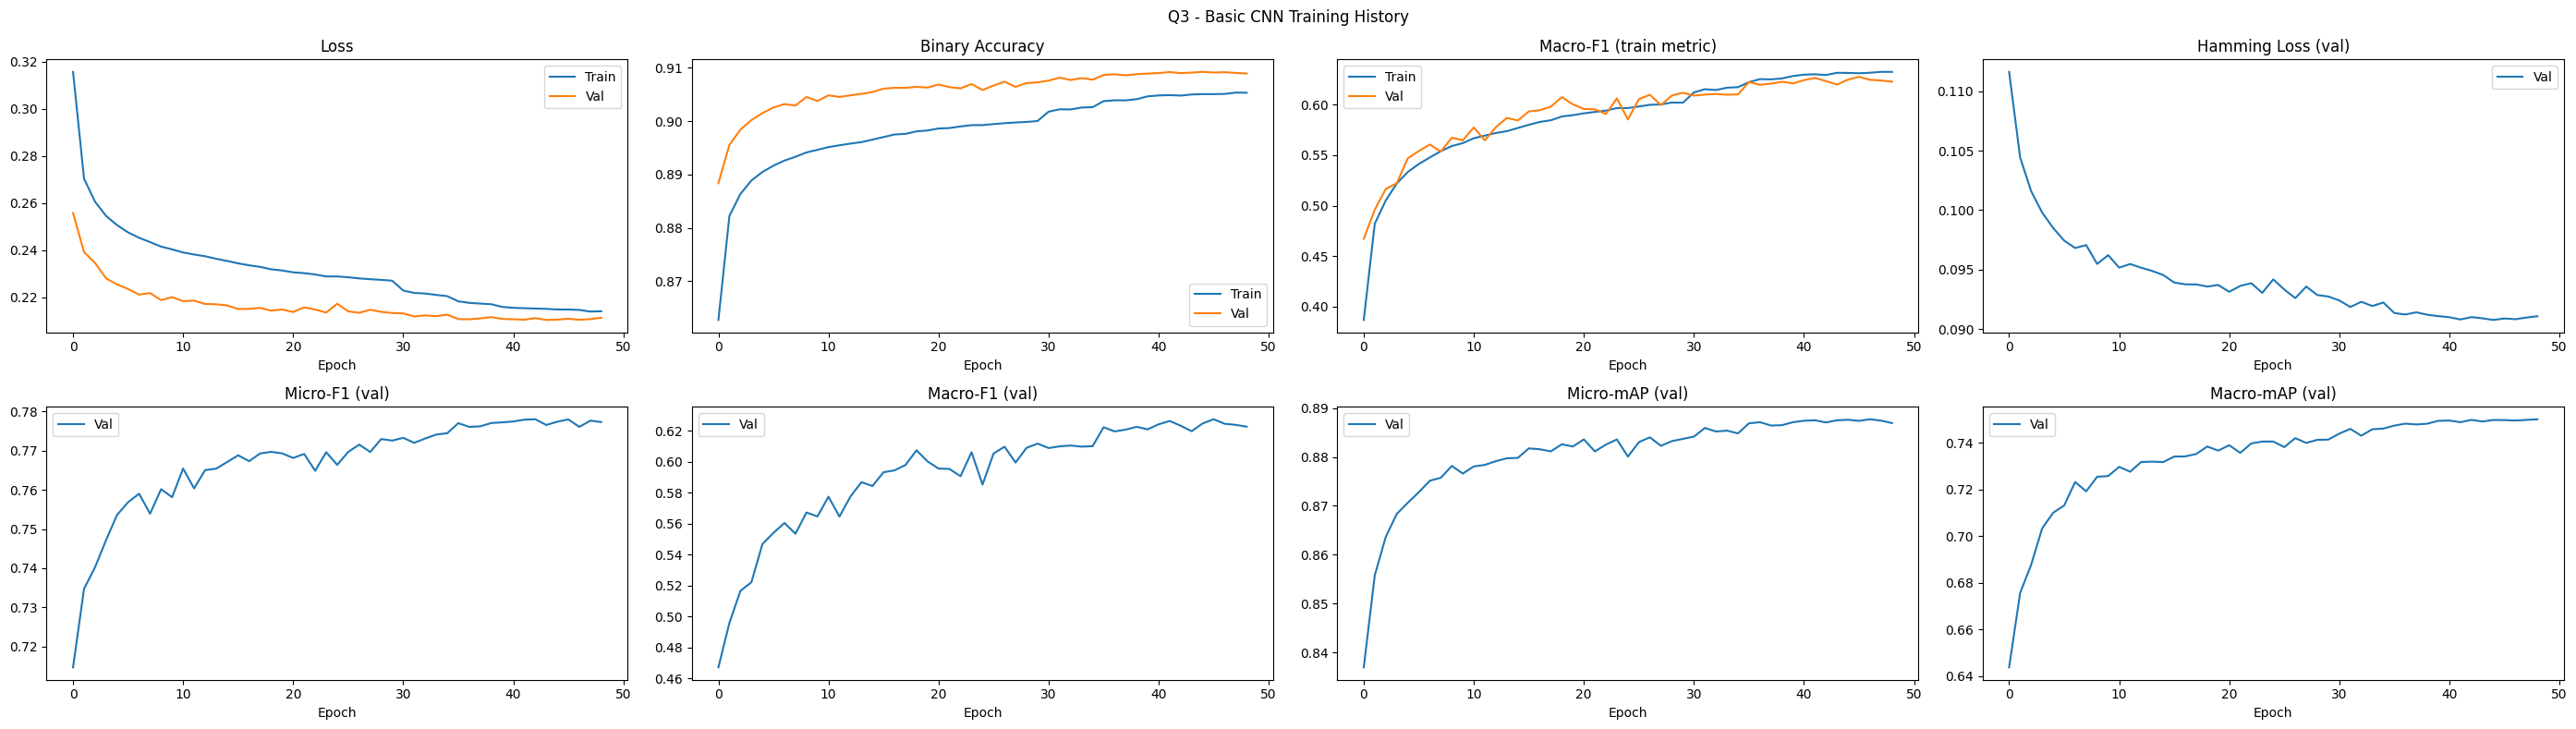

In [24]:
Q3_WEIGHTS = 'q3_basic_cnn.weights.h5'

callbacks_q3 = [
    full_metrics_cb,
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss', verbose=1),
    ModelCheckpoint(Q3_WEIGHTS, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Training Basic CNN...')
history_q3 = cnn_basic.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_q3,
    verbose=1
)

plot_training_history(history_q3, title='Q3 - Basic CNN Training History')

In [25]:
cnn_basic.load_weights(Q3_WEIGHTS)
q3_val_results,  _, _ = evaluate_model(cnn_basic, val_ds,  label='Q3 Val')
q3_test_results, _, _ = evaluate_model(cnn_basic, test_ds, label='Q3 Test')


--- Q3 Val Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.9091
  Hamming Loss        : 0.0909
  Micro-F1            : 0.7766
  Macro-F1            : 0.6197
  Micro-mAP           : 0.8875
  Macro-mAP           : 0.7491

--- Q3 Test Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.9036
  Hamming Loss        : 0.0964
  Micro-F1            : 0.7695
  Macro-F1            : 0.6159
  Micro-mAP           : 0.8880
  Macro-mAP           : 0.7471


### Improving from the baseline

An improved CNN with:
- **Batch Normalization** after each Conv layer (stabilizes training)
- **Deeper architecture** (4 blocks) with increasing filter depth
- **Global Average Pooling** instead of Flatten (reduces overfitting)
- **L2 Regularization** on Dense layers
- **Data Augmentation** (flip, brightness, contrast) to reduce overfitting

In [26]:
def build_advanced_cnn(input_shape=(64, 64, 3), num_classes=40):
    inputs = keras.Input(shape=input_shape)

    # Block 1: 32 filters
    x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 2: 64 filters
    x = layers.Conv2D(64, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 3: 128 filters
    x = layers.Conv2D(128, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Block 4: 256 filters
    x = layers.Conv2D(256, (3, 3), padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2, 2)(x)

    # Classifier head — deeper with two Dense layers
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu',
                     kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='sigmoid')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name='Advanced_CNN')
    return model


cnn_advanced = build_advanced_cnn()
cnn_advanced.summary()

cnn_advanced.compile(
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # lower LR for stability with augmentation
    loss='binary_crossentropy',
    metrics=['binary_accuracy', MacroF1Score(num_classes=NUM_CLASSES)]
)

Model: "Advanced_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 663,048 (2.53 MB)

 Trainable params: 662,088 (2.53 MB)

 Non-trainable params: 960 (3.75 KB)

Training Advanced CNN...
Epoch 1/50
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - binary_accuracy: 0.8381 - loss: 0.4066 - macro_f1: 0.2928
--- Epoch 1 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8753
  Hamming Loss        : 0.1247
  Micro-F1            : 0.6848
  Macro-F1            : 0.4812
  Micro-mAP           : 0.7999
  Macro-mAP           : 0.6402
1272/1272 ━━━━━━━━━━━━━━━━━━━━ 48s 31ms/step - binary_accuracy: 0.8381 - loss: 0.4066 - macro_f1: 0.2929 - val_binary_accuracy: 0.8753 - val_loss: 0.3027 - val_macro_f1: 0.4812 - val_hamming_loss: 0.1247 - val_micro_f1: 0.6848 - val_macro_f1_full: 0.4812 - val_micro_map: 0.7999 - val_macro_map: 0.6402 - learning_rate: 5.0000e-04
Epoch 2/50
1271/1272 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - binary_accuracy: 0.8856 - loss: 0.2778 - macro_f1: 0.5048
--- Epoch 2 Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.8699
  Hamming Loss        : 0.1301
  Micro-F1            : 0.7028
  Macro-F1            : 0.5260
  Micro-mAP           : 

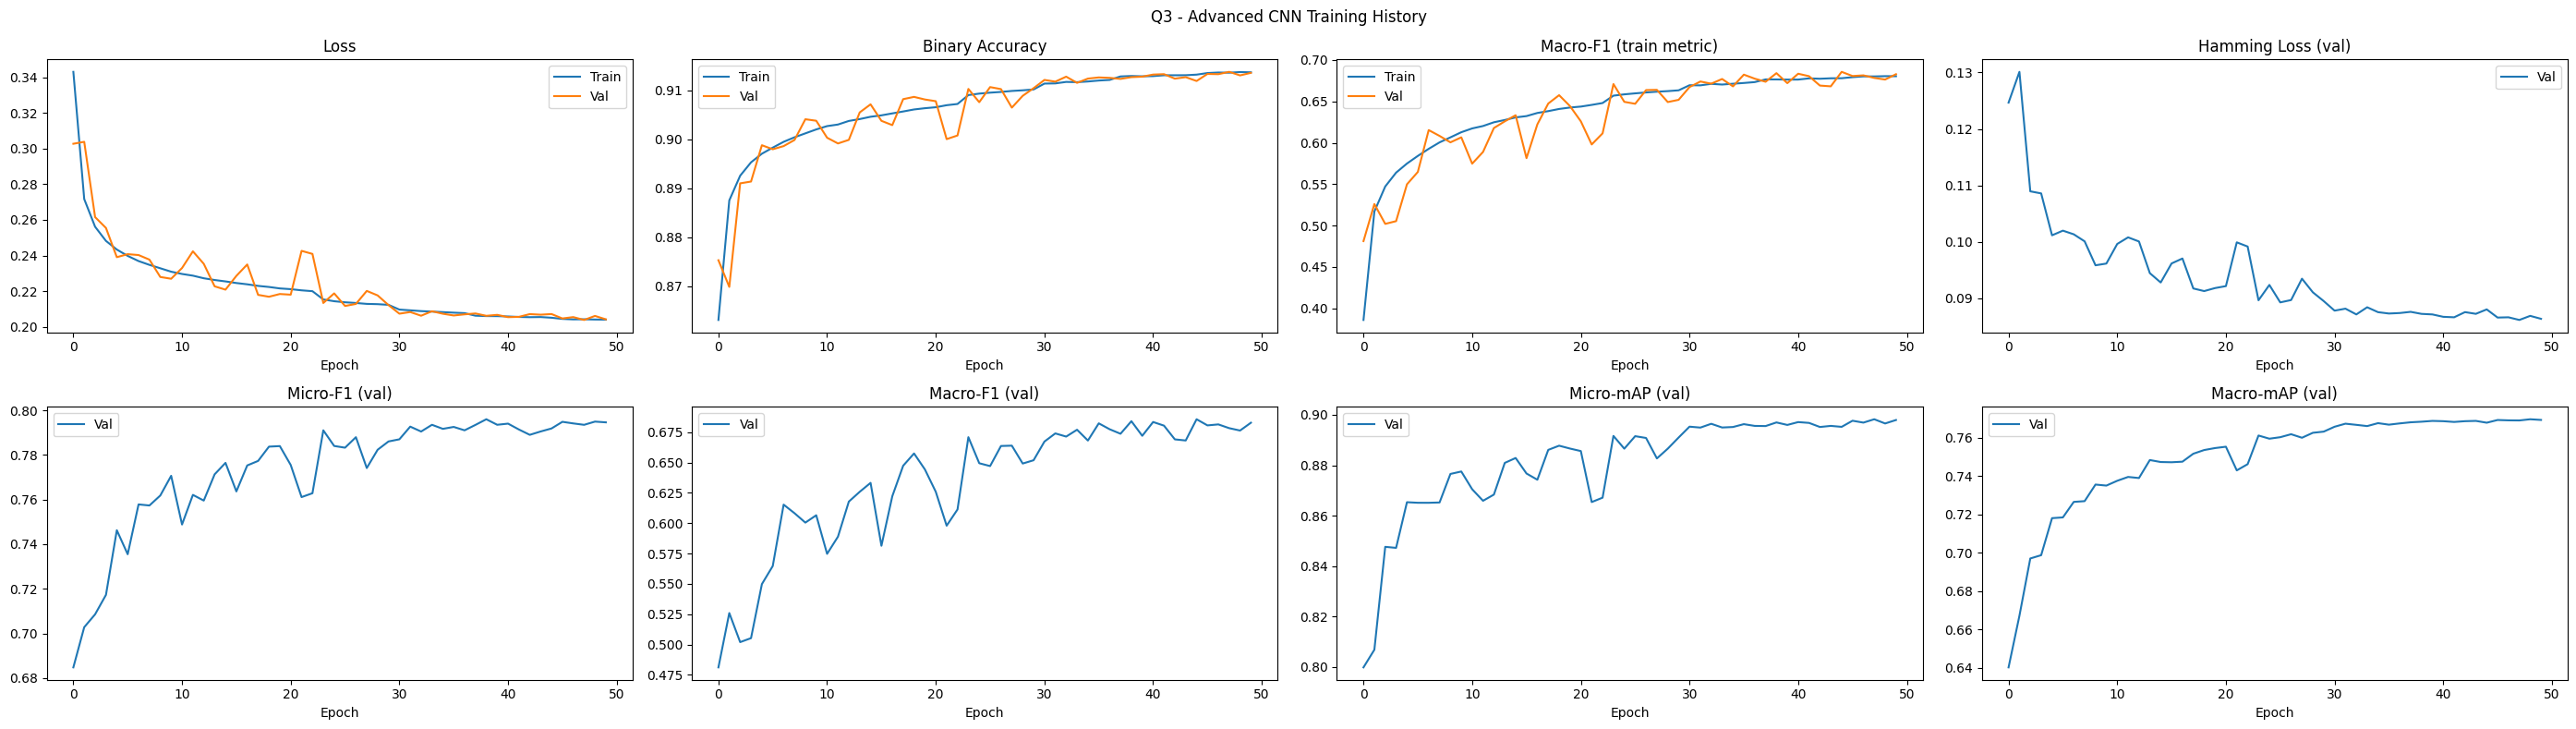

In [27]:
Q3_ADVANCED_WEIGHTS = 'q3_advanced_cnn.weights.h5'

callbacks_q3_advanced = [
    full_metrics_cb,
    EarlyStopping(patience=10, min_delta=1e-4, restore_best_weights=True, monitor='val_loss', verbose=1),
    ModelCheckpoint(Q3_ADVANCED_WEIGHTS, save_best_only=True, save_weights_only=True, monitor='val_loss', verbose=0),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)
]

print('Training Advanced CNN...')
history_q3 = cnn_advanced.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callbacks_q3_advanced,
    verbose=1
)

plot_training_history(history_q3, title='Q3 - Advanced CNN Training History')

In [28]:
cnn_advanced.load_weights(Q3_ADVANCED_WEIGHTS)
q3_val_results,  q3_y_true_val,  q3_y_prob_val  = evaluate_model(cnn_advanced, val_ds,  label='Q3 Advanced CNN Val')
q3_test_results, q3_y_true_test, q3_y_prob_test = evaluate_model(cnn_advanced, test_ds, label='Q3 Advanced CNN Test')


--- Q3 Advanced CNN Val Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.9138
  Hamming Loss        : 0.0862
  Micro-F1            : 0.7935
  Macro-F1            : 0.6784
  Micro-mAP           : 0.8982
  Macro-mAP           : 0.7689

--- Q3 Advanced CNN Test Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.9082
  Hamming Loss        : 0.0918
  Micro-F1            : 0.7857
  Macro-F1            : 0.6698
  Micro-mAP           : 0.8977
  Macro-mAP           : 0.7676


### Section 3 Analysis

#### Results
--- Q3 Advanced CNN Test Metrics (threshold=0.5) ---
* Binary Accuracy     : 0.9082
* Hamming Loss        : 0.0918
* Micro-F1            : 0.7857
* Macro-F1            : 0.6698
* Micro-mAP           : 0.8977
* Macro-mAP           : 0.7676

#### Comparing Advanced CNN and MLP Wider 
**Better Accuracy (+0.0149):**

The CNN achieved a final Binary Accuracy of 0.9082, a marginal but statistically significant step up from the Wider MLP’s 0.8933. While the 1024-neuron wide layer in Q2.3 provided enough capacity to "memorize" complex patterns, the CNN reaches a higher accuracy floor because its filters are mathematically designed to detect edges and shapes rather than just raw pixel intensities.

**Better Macro-F1 (+0.0555):**

"""In Thai, that's a fraction of a laughter hahaha, do you get it?"""

The Macro-F1 improved significantly from 0.6143 (Wider MLP) to 0.6698 (CNN). This increase proves that while a "Wide" MLP can handle global patterns, it still struggles with "Long-tail" or sparse attributes (e.g., Wearing Necktie or Mustache). The CNN’s local receptive fields allow it to isolate these small, specific textures that are otherwise "drowned out" in the massive 1024-neuron hidden layer of the MLP.

**Convergance speed (Epoch 46 vs. 29):**

Wider MLP (Q2.3): Stopping at epoch 29, Wider MLP has a shallow learning curve but a very low ceiling. This is because with 1024 neurons, it essentially tries to create a high-dimensional "lookup table" of pixel intensities. Once it has mapped the most common pixel configurations to labels, it stalls. 

Advanced CNN (Q3): Has a slower but more sustained convergence, eventually reaching a much deeper global minimum at epoch 46. This is because it takes longer to "warm up" because it must learn a hierarchy of features. In the early epochs, it is learning simple edges. Over the remaining epochs, it learns parts of a face and is refining the subtle textures that define rare attributes. 

**Generalisation:**

The Wider MLP is fundamentally limited by its "location sensitivity"—if a face is slightly off-center, the 1024 neurons must learn that new position from scratch. The CNN’s spatial inductive bias (via 2D convolution kernels) allows it to recognize a "nose" or "eye" regardless of where it appears in the frame. This makes the CNN significantly more robust to the natural variances found in the CelebA dataset.

**Architecture:**
The following architectures and optimisation techniques helped to improve performance in the Advanced CNN model:
* 2D Convolutions naturally "understand" that nearby pixels are related.
* Global Average Pooling (GAP) reduces parameters and prevents "location-specific" memorization.


---
## Section 4: Threshold Tuning & Analysis

1. **Global threshold tuning**: Find single best threshold $t \in \{0.1, 0.15, ..., 0.9\}$
2. **Per-attribute threshold tuning**: Find optimal $t_j$ for each attribute $j$
3. **Discussion**: Why 0.5 is suboptimal; Macro-F1 vs. Micro-F1 for rare attributes

Q4a: Searching global thresholds...
Best global threshold: 0.30  =>  Macro-F1: 0.7184


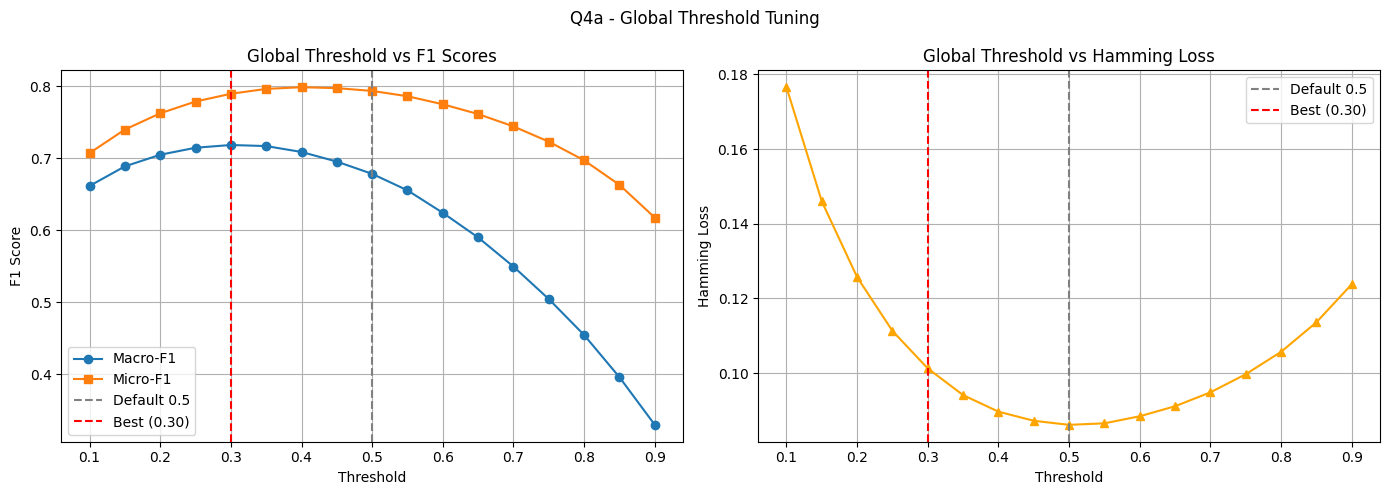

,threshold,macro_f1,micro_f1,hamming_loss
0,0.10,0.661633,0.707210,0.176538
1,0.15,0.688765,0.739878,0.145982
2,0.20,0.704905,0.762415,0.125710
3,0.25,0.714634,0.778755,0.111305
4,0.30,0.718425,0.789517,0.101277
5,0.35,0.716950,0.796293,0.094136
6,0.40,0.708745,0.798625,0.089709
7,0.45,0.695415,0.797336,0.087269
8,0.50,0.678384,0.793477,0.086183
9,0.55,0.655481,0.786111,0.086591


In [29]:
print('Q4a: Searching global thresholds...')
thresholds_to_try = np.arange(0.10, 0.95, 0.05)
global_results = []

for t in thresholds_to_try:
    y_pred = (q3_y_prob_val >= t).astype(int)
    macro_f1 = f1_score(q3_y_true_val, y_pred, average='macro',  zero_division=0)
    micro_f1 = f1_score(q3_y_true_val, y_pred, average='micro',  zero_division=0)
    h_loss   = hamming_loss(q3_y_true_val, y_pred)
    global_results.append({'threshold': t, 'macro_f1': macro_f1, 'micro_f1': micro_f1, 'hamming_loss': h_loss})

global_df = pd.DataFrame(global_results)

# Find best threshold by Macro-F1
best_global_row = global_df.loc[global_df['macro_f1'].idxmax()]
best_global_threshold = best_global_row['threshold']
print(f'Best global threshold: {best_global_threshold:.2f}  =>  Macro-F1: {best_global_row["macro_f1"]:.4f}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(global_df['threshold'], global_df['macro_f1'],  marker='o', label='Macro-F1')
axes[0].plot(global_df['threshold'], global_df['micro_f1'],  marker='s', label='Micro-F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
axes[0].axvline(x=best_global_threshold, color='red', linestyle='--', label=f'Best ({best_global_threshold:.2f})')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Global Threshold vs F1 Scores')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(global_df['threshold'], global_df['hamming_loss'], marker='^', color='orange')
axes[1].axvline(x=0.5, color='gray', linestyle='--', label='Default 0.5')
axes[1].axvline(x=best_global_threshold, color='red', linestyle='--', label=f'Best ({best_global_threshold:.2f})')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Hamming Loss')
axes[1].set_title('Global Threshold vs Hamming Loss')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Q4a - Global Threshold Tuning')
plt.tight_layout()
plt.show()

global_df

In [30]:
# ===== Q4b: Per-Attribute Threshold Tuning =====
print('Q4b: Per-attribute threshold tuning on validation set...')

per_attr_thresholds = np.zeros(NUM_CLASSES)
per_attr_f1_at_best = np.zeros(NUM_CLASSES)

for j in range(NUM_CLASSES):
    best_t_j = 0.5
    best_f1_j = 0.0
    for t in thresholds_to_try:
        y_pred_j = (q3_y_prob_val[:, j] >= t).astype(int)
        f1_j = f1_score(q3_y_true_val[:, j], y_pred_j, zero_division=0)
        if f1_j > best_f1_j:
            best_f1_j = f1_j
            best_t_j  = t
    per_attr_thresholds[j]  = best_t_j
    per_attr_f1_at_best[j]  = best_f1_j

print('Per-attribute optimal thresholds:')
thresh_df = pd.DataFrame({
    'Attribute': ATTR_NAMES,
    'Best_Threshold': per_attr_thresholds,
    'Best_Val_F1':    per_attr_f1_at_best,
    'Prevalence':     attr_prevalence
}).sort_values('Prevalence')

thresh_df.head(10)

Q4b: Per-attribute threshold tuning on validation set...
Per-attribute optimal thresholds:


,Attribute,Best_Threshold,Best_Val_F1,Prevalence
4,Bald,0.35,0.709236,0.022811
22,Mustache,0.30,0.581478,0.040806
17,Gray_Hair,0.35,0.774384,0.042367
26,Pale_Skin,0.35,0.580161,0.043036
14,Double_Chin,0.30,0.591481,0.046513
35,Wearing_Hat,0.35,0.877842,0.049389
10,Blurry,0.30,0.554455,0.051373
30,Sideburns,0.35,0.723168,0.056251
13,Chubby,0.25,0.584986,0.057683
16,Goatee,0.35,0.750544,0.063507


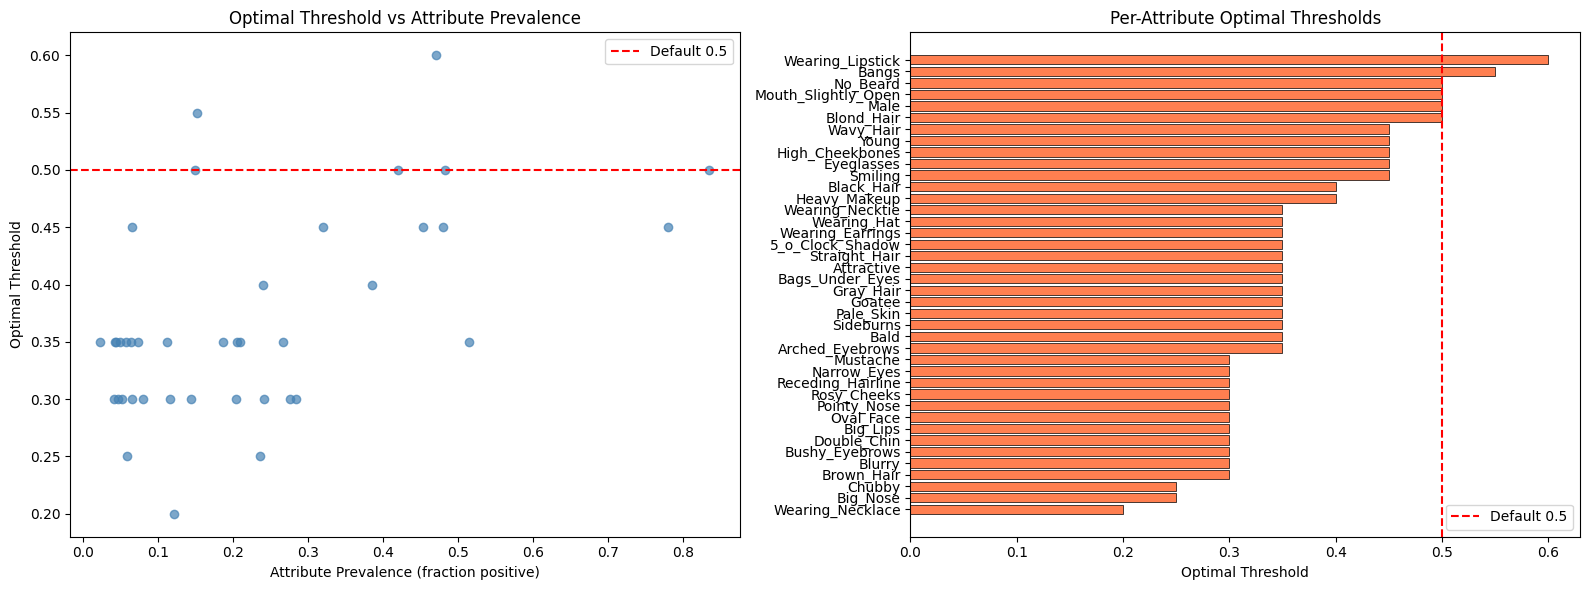

In [31]:
# Visualize per-attribute thresholds vs prevalence
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(thresh_df['Prevalence'], thresh_df['Best_Threshold'], alpha=0.7, c='steelblue')
axes[0].axhline(0.5, color='red', linestyle='--', label='Default 0.5')
axes[0].set_xlabel('Attribute Prevalence (fraction positive)')
axes[0].set_ylabel('Optimal Threshold')
axes[0].set_title('Optimal Threshold vs Attribute Prevalence')
axes[0].legend()

# Bar: optimal thresholds sorted by attribute
idx = np.argsort(per_attr_thresholds)
axes[1].barh([ATTR_NAMES[i] for i in idx], per_attr_thresholds[idx], color='coral', edgecolor='black', linewidth=0.5)
axes[1].axvline(0.5, color='red', linestyle='--', label='Default 0.5')
axes[1].set_xlabel('Optimal Threshold')
axes[1].set_title('Per-Attribute Optimal Thresholds')
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
# ===== Evaluate tuned thresholds on TEST set =====
print('Evaluating all threshold strategies on TEST set...')

# Default 0.5
res_default, _, _ = evaluate_model(cnn_advanced, test_ds, threshold=0.5, label='Q3 Default (t=0.5)')

# Global best threshold
res_global,  _, _ = evaluate_model(cnn_advanced, test_ds, threshold=best_global_threshold,
                                    label=f'Q4a Global (t={best_global_threshold:.2f})')

# Per-attribute thresholds
# We supply y_prob from test set and manually compute
y_pred_per_attr = (q3_y_prob_test >= per_attr_thresholds[np.newaxis, :]).astype(int)

bin_acc_pa   = np.mean(y_pred_per_attr == q3_y_true_test)
h_loss_pa    = hamming_loss(q3_y_true_test, y_pred_per_attr)
micro_f1_pa  = f1_score(q3_y_true_test, y_pred_per_attr, average='micro', zero_division=0)
macro_f1_pa  = f1_score(q3_y_true_test, y_pred_per_attr, average='macro', zero_division=0)
micro_map_pa = average_precision_score(q3_y_true_test, q3_y_prob_test, average='micro')
macro_map_pa = average_precision_score(q3_y_true_test, q3_y_prob_test, average='macro')

res_per_attr = {
    'Binary Accuracy': bin_acc_pa,
    'Hamming Loss':    h_loss_pa,
    'Micro-F1':        micro_f1_pa,
    'Macro-F1':        macro_f1_pa,
    'Micro-mAP':       micro_map_pa,
    'Macro-mAP':       macro_map_pa
}
print('\n--- Q4b Per-Attribute Threshold Test Metrics ---')
for k, v in res_per_attr.items():
    print(f'  {k:20s}: {v:.4f}')

Evaluating all threshold strategies on TEST set...

--- Q3 Default (t=0.5) Metrics (threshold=0.5) ---
  Binary Accuracy     : 0.9082
  Hamming Loss        : 0.0918
  Micro-F1            : 0.7857
  Macro-F1            : 0.6698
  Micro-mAP           : 0.8977
  Macro-mAP           : 0.7676

--- Q4a Global (t=0.30) Metrics (threshold=0.3) ---
  Binary Accuracy     : 0.8969
  Hamming Loss        : 0.1031
  Micro-F1            : 0.7907
  Macro-F1            : 0.7144
  Micro-mAP           : 0.8977
  Macro-mAP           : 0.7676

--- Q4b Per-Attribute Threshold Test Metrics ---
  Binary Accuracy     : 0.8976
  Hamming Loss        : 0.1024
  Micro-F1            : 0.7874
  Macro-F1            : 0.7171
  Micro-mAP           : 0.8977
  Macro-mAP           : 0.7676


### Section 4 Summary Table

                 Binary Accuracy  Hamming Loss  Micro-F1  Macro-F1  Micro-mAP  \
Strategy                                                                        
Default (t=0.5)           0.9082        0.0918    0.7857    0.6698     0.8977   
Global (t=0.30)           0.8969        0.1031    0.7907    0.7144     0.8977   
Per-Attribute             0.8976        0.1024    0.7874    0.7171     0.8977   

                 Macro-mAP  
Strategy                    
Default (t=0.5)     0.7676  
Global (t=0.30)     0.7676  
Per-Attribute       0.7676  


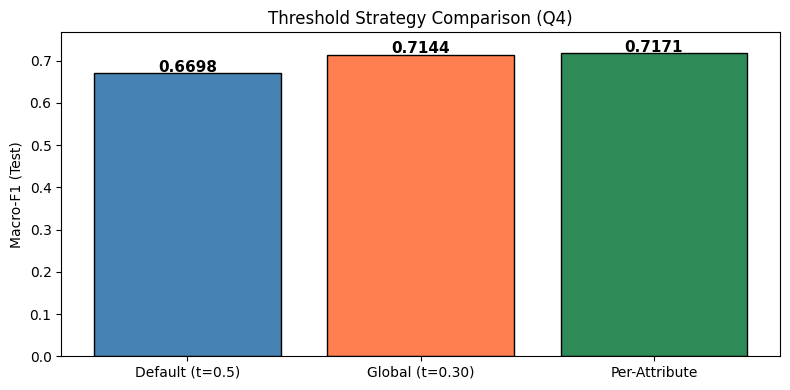

In [33]:
summary = pd.DataFrame([
    {'Strategy': 'Default (t=0.5)',           **res_default},
    {'Strategy': f'Global (t={best_global_threshold:.2f})', **res_global},
    {'Strategy': 'Per-Attribute',             **res_per_attr}
])

summary.set_index('Strategy', inplace=True)
summary = summary.round(4)
print(summary)

# Visual bar comparison for Macro-F1
fig, ax = plt.subplots(figsize=(8, 4))
strategies = summary.index.tolist()
macro_f1s  = summary['Macro-F1'].values
bars = ax.bar(strategies, macro_f1s, color=['steelblue', 'coral', 'seagreen'], edgecolor='black')
for bar, val in zip(bars, macro_f1s):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, f'{val:.4f}',
            ha='center', fontsize=11, fontweight='bold')
ax.set_ylabel('Macro-F1 (Test)')
ax.set_title('Threshold Strategy Comparison (Q4)')
ax.set_ylim(0, max(macro_f1s) + 0.05)
plt.tight_layout()
plt.show()

### Section 4 Evaluation

**Suboptimality of the 0.5 Threshold**

Using a fixed threshold of 0.5 is suboptimal for the CelebA dataset because of the class imbalance. For rare attributes (e.g., "Bald" or "Mustache"), the model’s predicted probabilities may rarely cross the 0.5 mark, leading to an artificially high false-negative rate. Conversely, for dominant attributes (e.g., "Young"), 0.5 may be too lenient, resulting in lower precision. Customizing the threshold allows the model to "calibrate" its sensitivity to the specific prevalence of each of the 40 features.

**Macro-F1 vs. Micro-F1 Sensitivity**

* Macro-F1: This metric calculates the F1 score for each of the 40 attributes independently and then takes the unweighted average. Because every attribute—regardless of how many samples it has—contributes 1/40 to the final score, it is highly sensitive to rare attributes. A poor performance on a rare class like "Goatee" will pull the Macro-F1 down significantly.
* Micro-F1: This metric aggregates the total true positives, false negatives, and false positives across all classes to calculate a global score. It is dominated by the most common attributes (like "Young" or "Attractive"), effectively "masking" poor performance on the rare ones.

**Method Comparison: Global vs. Per-Attribute**

While a global threshold shift (finding one best value for all 40 classes) provides a minor baseline boost, it cannot account for the varying densities of the CelebA attributes. Per-attribute optimization (using a validation search) allows the model to set a lower threshold for rare classes (to capture more true positives) and a higher threshold for dominant classes (to reduce false positives). We know this was the superior method because the Macro-F1 saw a much larger relative jump after per-attribute tuning compared to the global shift.